<a href="https://colab.research.google.com/github/chomingi-25/2026_tues_bigdatacomputing_class/blob/main/%EB%8B%A4%EC%A4%91_%ED%8A%B9%EC%84%B1_%ED%9A%8C%EA%B7%80_%EB%AA%A8%EB%8D%B8_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EA%B5%AC%EC%B6%95_%EB%B0%8F_Streamlit_%EC%9B%B9_%EC%84%9C%EB%B9%84%EC%8A%A4_%EB%B0%B0%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0단계
- 실습 환경 구축

In [1]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.4 MB/s eta 0:00:00


## 1단계
- 데이터 준비 및 소규모 훈련 샘플링
- 파이프라인 기반 모델 3종 학습 및 저장

In [2]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 로드
url="https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df=pd.read_csv(url) # CSV 파일 읽기
df.columns = df.columns.str.strip() # 컬럼명 앞뒤 공백 제거
df=df.dropna() # 결측치 제거
features=['Adult mortality', 'BMI', 'GDP', 'Alcohol'] # 사용할 독립변수 선택
target='Life expectancy' # 종속변수 선택
X=df[features] # 독립변수 데이터 저장
y=df[target] # 종속변수 데이터 저장
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=50) # 학습용 80%, 테스트용 20% 분할

# 2. 모델 생성
# 선형회귀 모델
linear_model=Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("lr", LinearRegression()) # 선형회귀 적용
])
# 다항회귀 모델
poly_model=Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("poly", PolynomialFeatures(degree=3)), # 3차 다항 특성 생성
        ("lr", LinearRegression()) # 선형회귀 적용
])
# Ridge 모델
ridge_model=Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("poly", PolynomialFeatures(degree=3)), # 3차 다항 특성 생성
        ("ridge", Ridge(alpha=1.0)) # Ridge 규제 적용
])

# 3. 모델 학습
linear_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
# 4. 성능 비교 데이터 생성
results=[] # 성능 결과 저장용 리스트

# 5. 모델을 pkl 파일로 저장
joblib.dump(linear_model, 'linear.pkl')
joblib.dump(poly_model, 'poly.pkl')
joblib.dump(ridge_model, 'ridge.pkl')

# 6. app.py에서 사용할 데이터 저장
df.to_csv("life_expectancy.csv", index=False)

# 7. 저장 완료 메시지 출력
print("linear.pkl 파일, poly.pkl 파일, ridge.pkl 파일 저장 완료")

linear.pkl 파일, poly.pkl 파일, ridge.pkl 파일 저장 완료


## 2단계
- 모델 성능 비교

=== 모델 성능 비교 ===


,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.6587,0.6243,27.4288,24.4468,4
1,Poly,0.8120,0.7830,15.1030,14.1198,35
2,Ridge,0.8120,0.7832,15.1037,14.1074,35


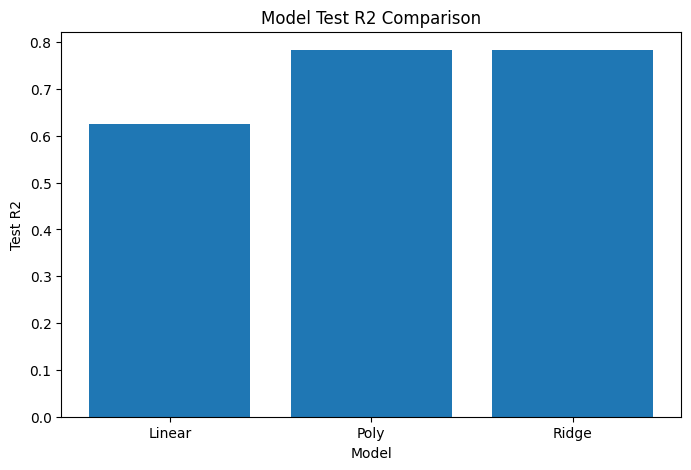


=== 최고 성능 모델 ===
모델 : Ridge
Test R2 : 0.7832
Test MSE : 14.1074
Complexity : 35


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
import warnings

# 0. 경고 무시
warnings.filterwarnings("ignore", category=UserWarning)

# 1. 모델 성능 비교
results=[] # 성능 결과 저장용 리스트 생성
models={
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
} # 비교할 모델들을 딕셔너리 형태로 저장
for name, model in models.items():     # models 딕셔너리에서 모델 이름과 모델 객체를 하나씩 꺼냄
  train_pred=model.predict(X_train) # 학습 데이터에 대한 예측값 생성
  test_pred=model.predict(X_test)      # 테스트 데이터에 대한 예측값 생성
  train_r2=r2_score(y_train, train_pred)  # 학습 데이터의 R2 점수 계산
  test_r2=r2_score(y_test, test_pred)  # 테스트 데이터의 R2 점수 계산
  train_mse=mean_squared_error(y_train, train_pred)  # 학습 데이터의 MSE 계산
  test_mse=mean_squared_error(y_test, test_pred)   # 테스트 데이터의 MSE 계산
  if name=="Linear":
    complexity=X_train.shape[1] # 원본 특성 개수 저장
  else:
    complexity=model.named_steps['poly'].transform(X_train).shape[1] # 다항 회귀 모델로 변환 후 특성 개수
  results.append({ # 성능 결과를 딕셔너리 형태로 리스트에 추가
      "Model":name,    # 모델 이름 저장
      "Train R2": round(train_r2, 4),    # 학습 데이터 R2를 소수점 4자리로 저장
      "Test R2":round(test_r2, 4),      # 테스트 데이터 R2를 소수점 4자리로 저장
      "Train MSE":round(train_mse, 4),  # 학습 데이터 MSE를 소수점 4자리로 저장
      "Test MSE":round(test_mse, 4),    # 테스트 데이터 MSE를 소수점 4자리로 저장
      "Complexity":complexity           # 모델 복잡도 저장
  })   # 현재 모델의 성능 결과 저장 완료
result_df=pd.DataFrame(results) # 결과를 데이터프레임으로 변환
# 2. 모델 성능 비교 결과 출력
print("=== 모델 성능 비교 ===")  # 출력 제목 표시
display(result_df) # 성능 비교 테이블 출력
joblib.dump(result_df, "result_df.pkl")
fig, ax=plt.subplots(figsize=(8, 5)) # 막대그래프 크기 설정
ax.bar(
    result_df["Model"],    # x축 : 모델 이름
    result_df["Test R2"]  # y축 : 테스트 R2
) # 모델별 Test R2 비교 그래프 생성
ax.set_title("Model Test R2 Comparison") # 그래프 제목 설정
ax.set_xlabel("Model") # x축 이름 설정
ax.set_ylabel("Test R2") # y축 이름 설정
plt.show() # 그래프 출력
best_idx=result_df["Test R2"].idxmax() # Test R2가 가장 높은 모델의 인덱스 찾기
best_model=result_df.loc[best_idx] # 최고 성능 모델 정보 추출
print() # 빈 줄 출력
print("=== 최고 성능 모델 ===") # 최고 성능 모델 출력 제목
print("모델 :", best_model["Model"]) # 최고 성능 모델 이름 출력
print("Test R2 :", best_model["Test R2"]) # 최고 성능 모델의 Test R2 출력
print("Test MSE :", best_model["Test MSE"]) # 최고 성능 모델의 Test MSE 출력
print("Complexity :", best_model["Complexity"]) # 최고 성능 모델의 복잡도 출력

## 3단계
- app.py 실행

In [4]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 1. 저장된 pkl 데이터 로드
linear_model=joblib.load("linear.pkl")
poly_model=joblib.load("poly.pkl")
ridge_model=joblib.load("ridge.pkl")
result_df=joblib.load("result_df.pkl")
df=pd.read_csv("life_expectancy.csv")
X=df[["Adult mortality", "BMI", "GDP", "Alcohol"]]
models={
    "Linear":linear_model,
    "Poly": poly_model,
    "Ridge":ridge_model
} # 저장된 모델 딕셔너리 불러오기

# 2. Streamlit 웹 페이지 기본 설정
st.set_page_config(
    page_title="Life Expectancy Prediction", # 웹 페이지 제목 설정
    layout="centered"  # 화면 배치를 가운데 정렬
)
# 3. 페이지 설정
st.title("Life Expectancy Prediction")   # 웹 앱 제목 출력

# 4. Sidebar 설정
st.sidebar.header("모델 선택 및 데이터 입력")   # 사이드바 제목 출력
selected_model_name=st.sidebar.selectbox(  # 모델 선택 드롭다운 생성
    "예측에 사용할 모델 선택",   # 드롭다운 안내
    ["Linear", "Poly", "Ridge"]
)     # 선택 가능한 모델 이름 목록
current_pipeline=models[selected_model_name]   # 사용자가 선택한 모델 객체 가져오기
adult=st.sidebar.slider(  # Adult mortality 값을 입력받는 사이드바 슬라이더 생성
    "Adult mortality",    # 슬라이더에 표시할 이름
    float(X["Adult mortality"].min()),   # 슬라이더의 최솟값을 데이터의 최솟값으로 설정
    float(X["Adult mortality"].max()),   # 슬라이더의 최댓값을 데이터의 최댓값으로 설정
    float(X["Adult mortality"].mean())   # 슬라이더의 기본값을 데이터의 평균값으로 설정
)
bmi=st.sidebar.slider(    # BMI 값을 입력받는 사이드바 슬라이더 생성
    "BMI",                # 슬라이더에 표시할 이름
    float(X["BMI"].min()),   # 슬라이더의 최솟값을 BMI 최솟값으로 설정
    float(X["BMI"].max()),   # 슬라이더의 최댓값을 BMI 최댓값으로 설정
    float(X["BMI"].mean())   # 슬라이더의 기본값을 BMI 평균값으로 설정
)
gdp=st.sidebar.slider(    # GDP 값을 입력받는 사이드바 슬라이더 생성
    "GDP",                # 슬라이더에 표시할 이름
    float(X["GDP"].min()),   # 슬라이더의 최솟값을 GDP 최솟값으로 설정
    float(X["GDP"].max()),   # 슬라이더의 최댓값을 GDP 최댓값으로 서정
    float(X["GDP"].mean())   # 슬라이더의 기본값을 GDP 평균값으로 설정
)
alcohol=st.sidebar.slider(   # Alcohol 값을 입력받는 사이드바 슬라이더 생성
    "Alcohol",               # 슬라이더에 표시할 이름
    float(X["Alcohol"].min()),   # 슬라이더의 최솟값을 Alcohol 최솟값으로 설정
    float(X["Alcohol"].max()),   # 슬라이더의 최댓값을 Alcohol 최댓값으로 설정
    float(X["Alcohol"].mean())   # 슬라이더의 기본값을 Alcohol 평균값으로 설정
)
input_df=pd.DataFrame({      # 사용자가 입력한 값을 데이터프레임으로 생성
    'Adult mortality':[adult],   # Adult mortality 입력값 저장
    'BMI':[bmi],             # BMI 입력값 저장
    'GDP':[gdp],             # GDP 입력값 저장
    'Alcohol':[alcohol]      # Alcohol 입력값 저장
})
prediction=current_pipeline.predict(input_df)  # 선택한 모델로 기대수명 예측
st.subheader("선택 모델 : {}".format(selected_model_name))  # 예측 기대수명 결과 출력
st.success("예상 기대수명 : {:.2f} 세".format(prediction[0]))  # 예측 기대수명 결과 출력
selected_result=result_df[result_df["Model"]==selected_model_name]
test_r2=selected_result["Test R2"].iloc[0]
# 5. 성능 비교
st.subheader("모델 성능 비교") # 모델 성능 비교 제목 출력
st.dataframe(result_df)       # 모델별 성능 비교 테이블 출력
# 6. 그래프 시각화
fig, ax=plt.subplots(figsize=(8, 5))   # 그래프 객체 생성
ax.bar(     # 막대그래프 생성
    result_df["Model"], # x축 : 모델 이름
    result_df["Test R2"]  # y축 : Test R2 값
)
ax.set_title("{} (Test R2={:.4f})".format(selected_model_name, test_r2))  # 그래프 제목 설정
ax.set_xlabel("Model") # x축 이름 설정
ax.set_ylabel("Test R2") # y축 이름 설정
st.pyplot(fig)     # Streamlit 화면에 그래프 출력

Writing app.py


## 4단계
- ngrok 연결

In [5]:
# 기존 코드를 멈추고 아래 코드로 다시 실행
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 열려 있을 가능성이 있는 기존 터널 모두 닫
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3Dw1lJLpfOQWowerEZaVV7EPgLo_511PeWA4FgnT4YWE4LU36")

# 3. Streamlit 실행(서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("streamlit run app.py --server.address 127.0.0.1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결(8501 포트 열기)
public_url=ngrok.connect(8501)

# 5. 링크로 이동할 수 있도록 화면에 링크 출력
print("아래 링크를 클릭하세요:\n{}".format(public_url))

아래 링크를 클릭하세요:
NgrokTunnel: "https://snack-headfirst-unsalted.ngrok-free.dev" -> "http://localhost:8501"


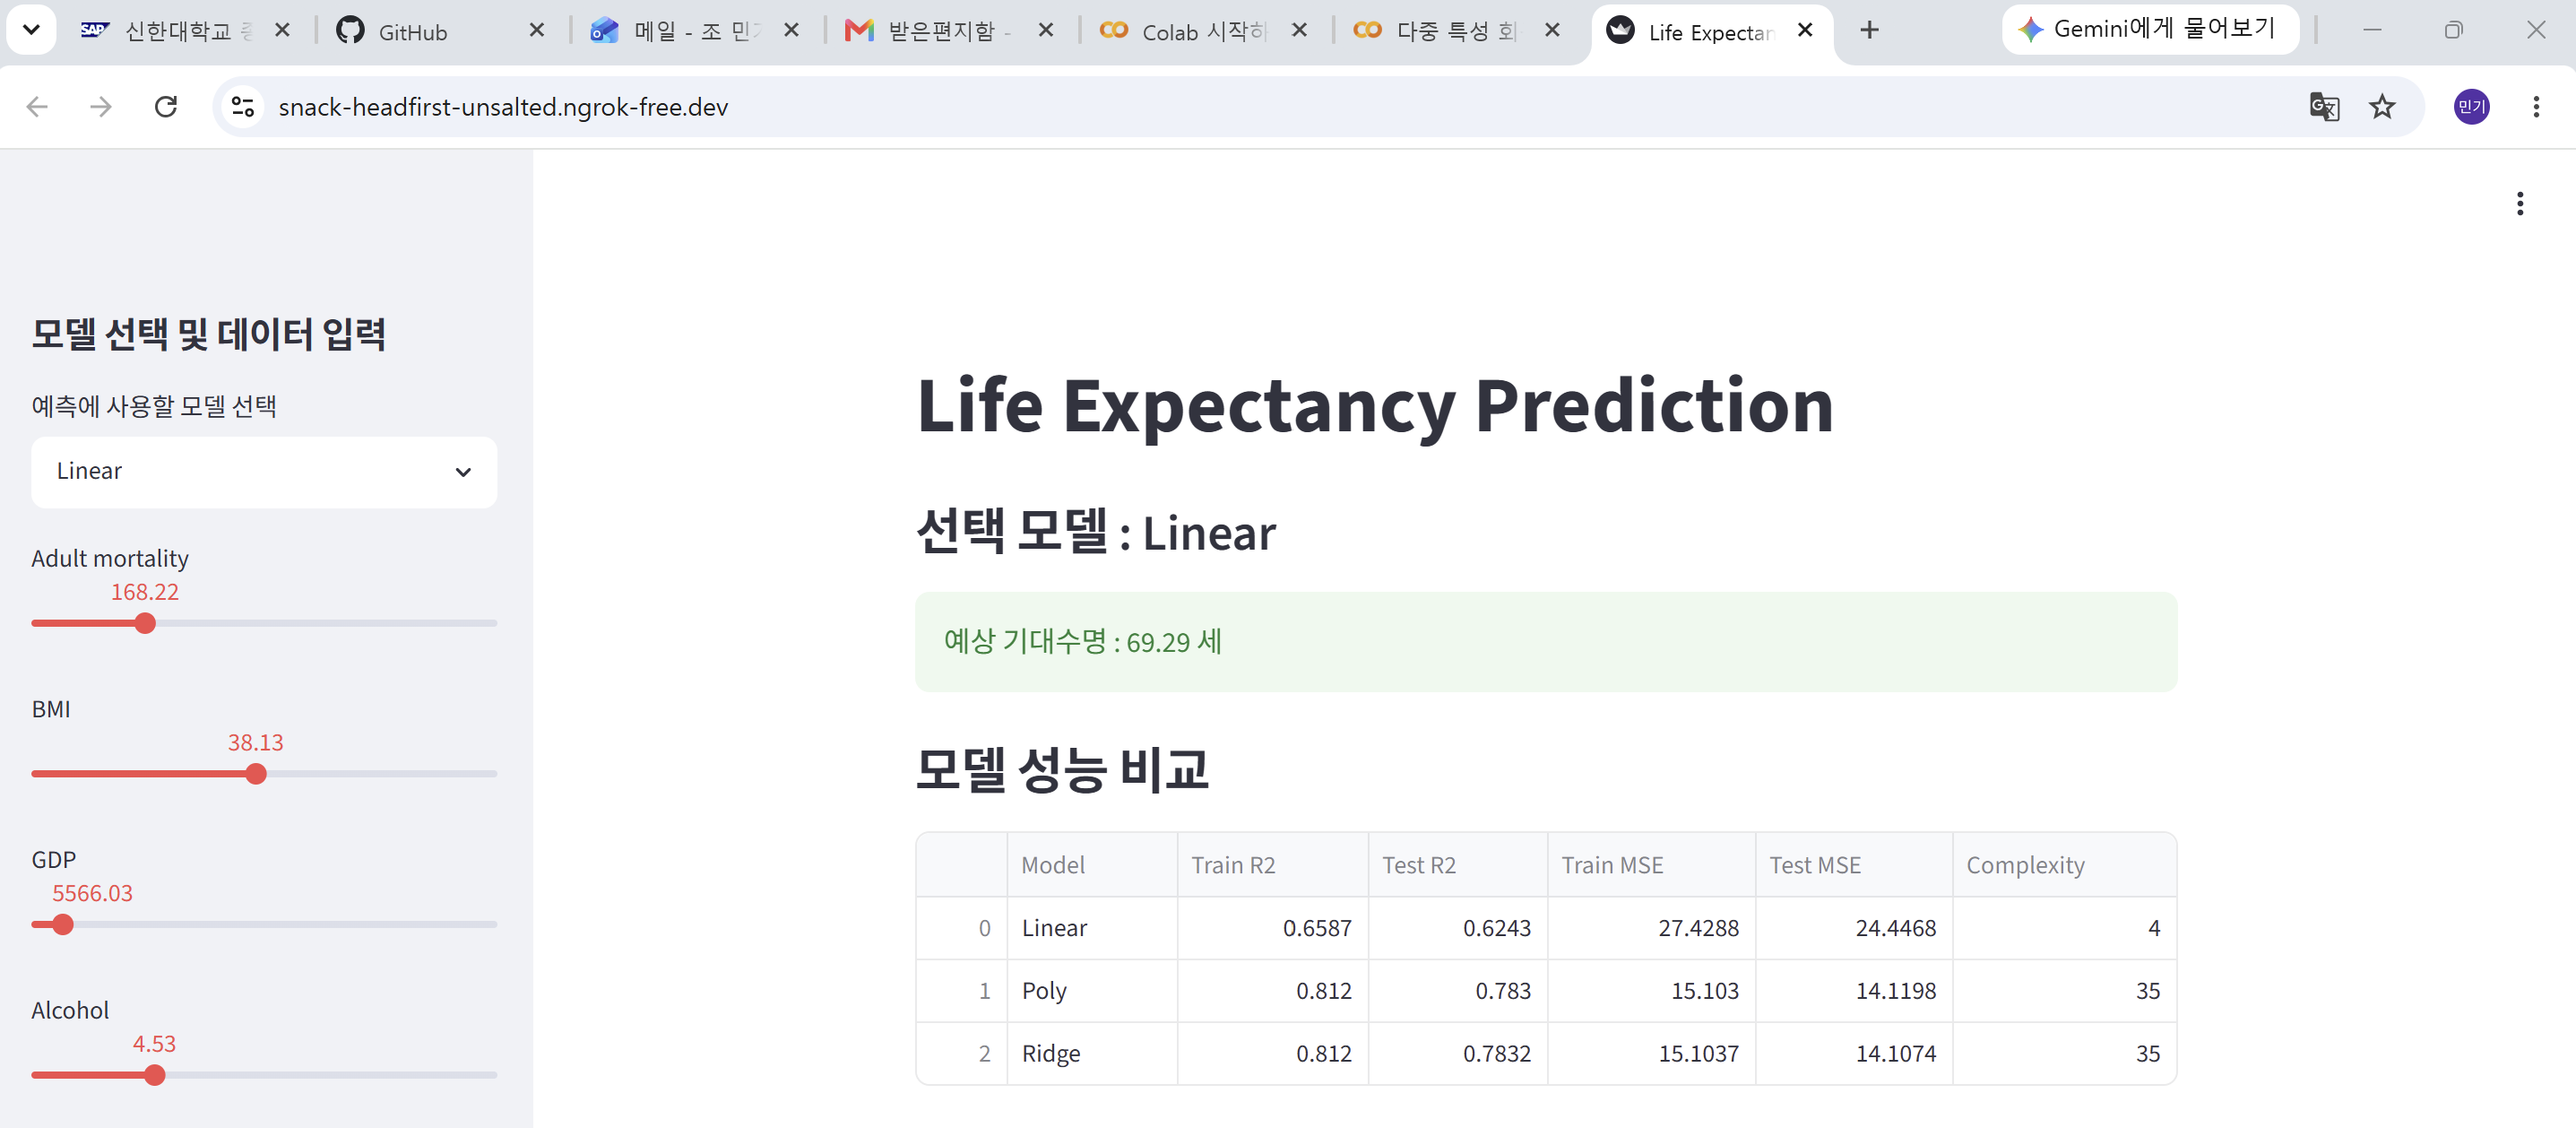

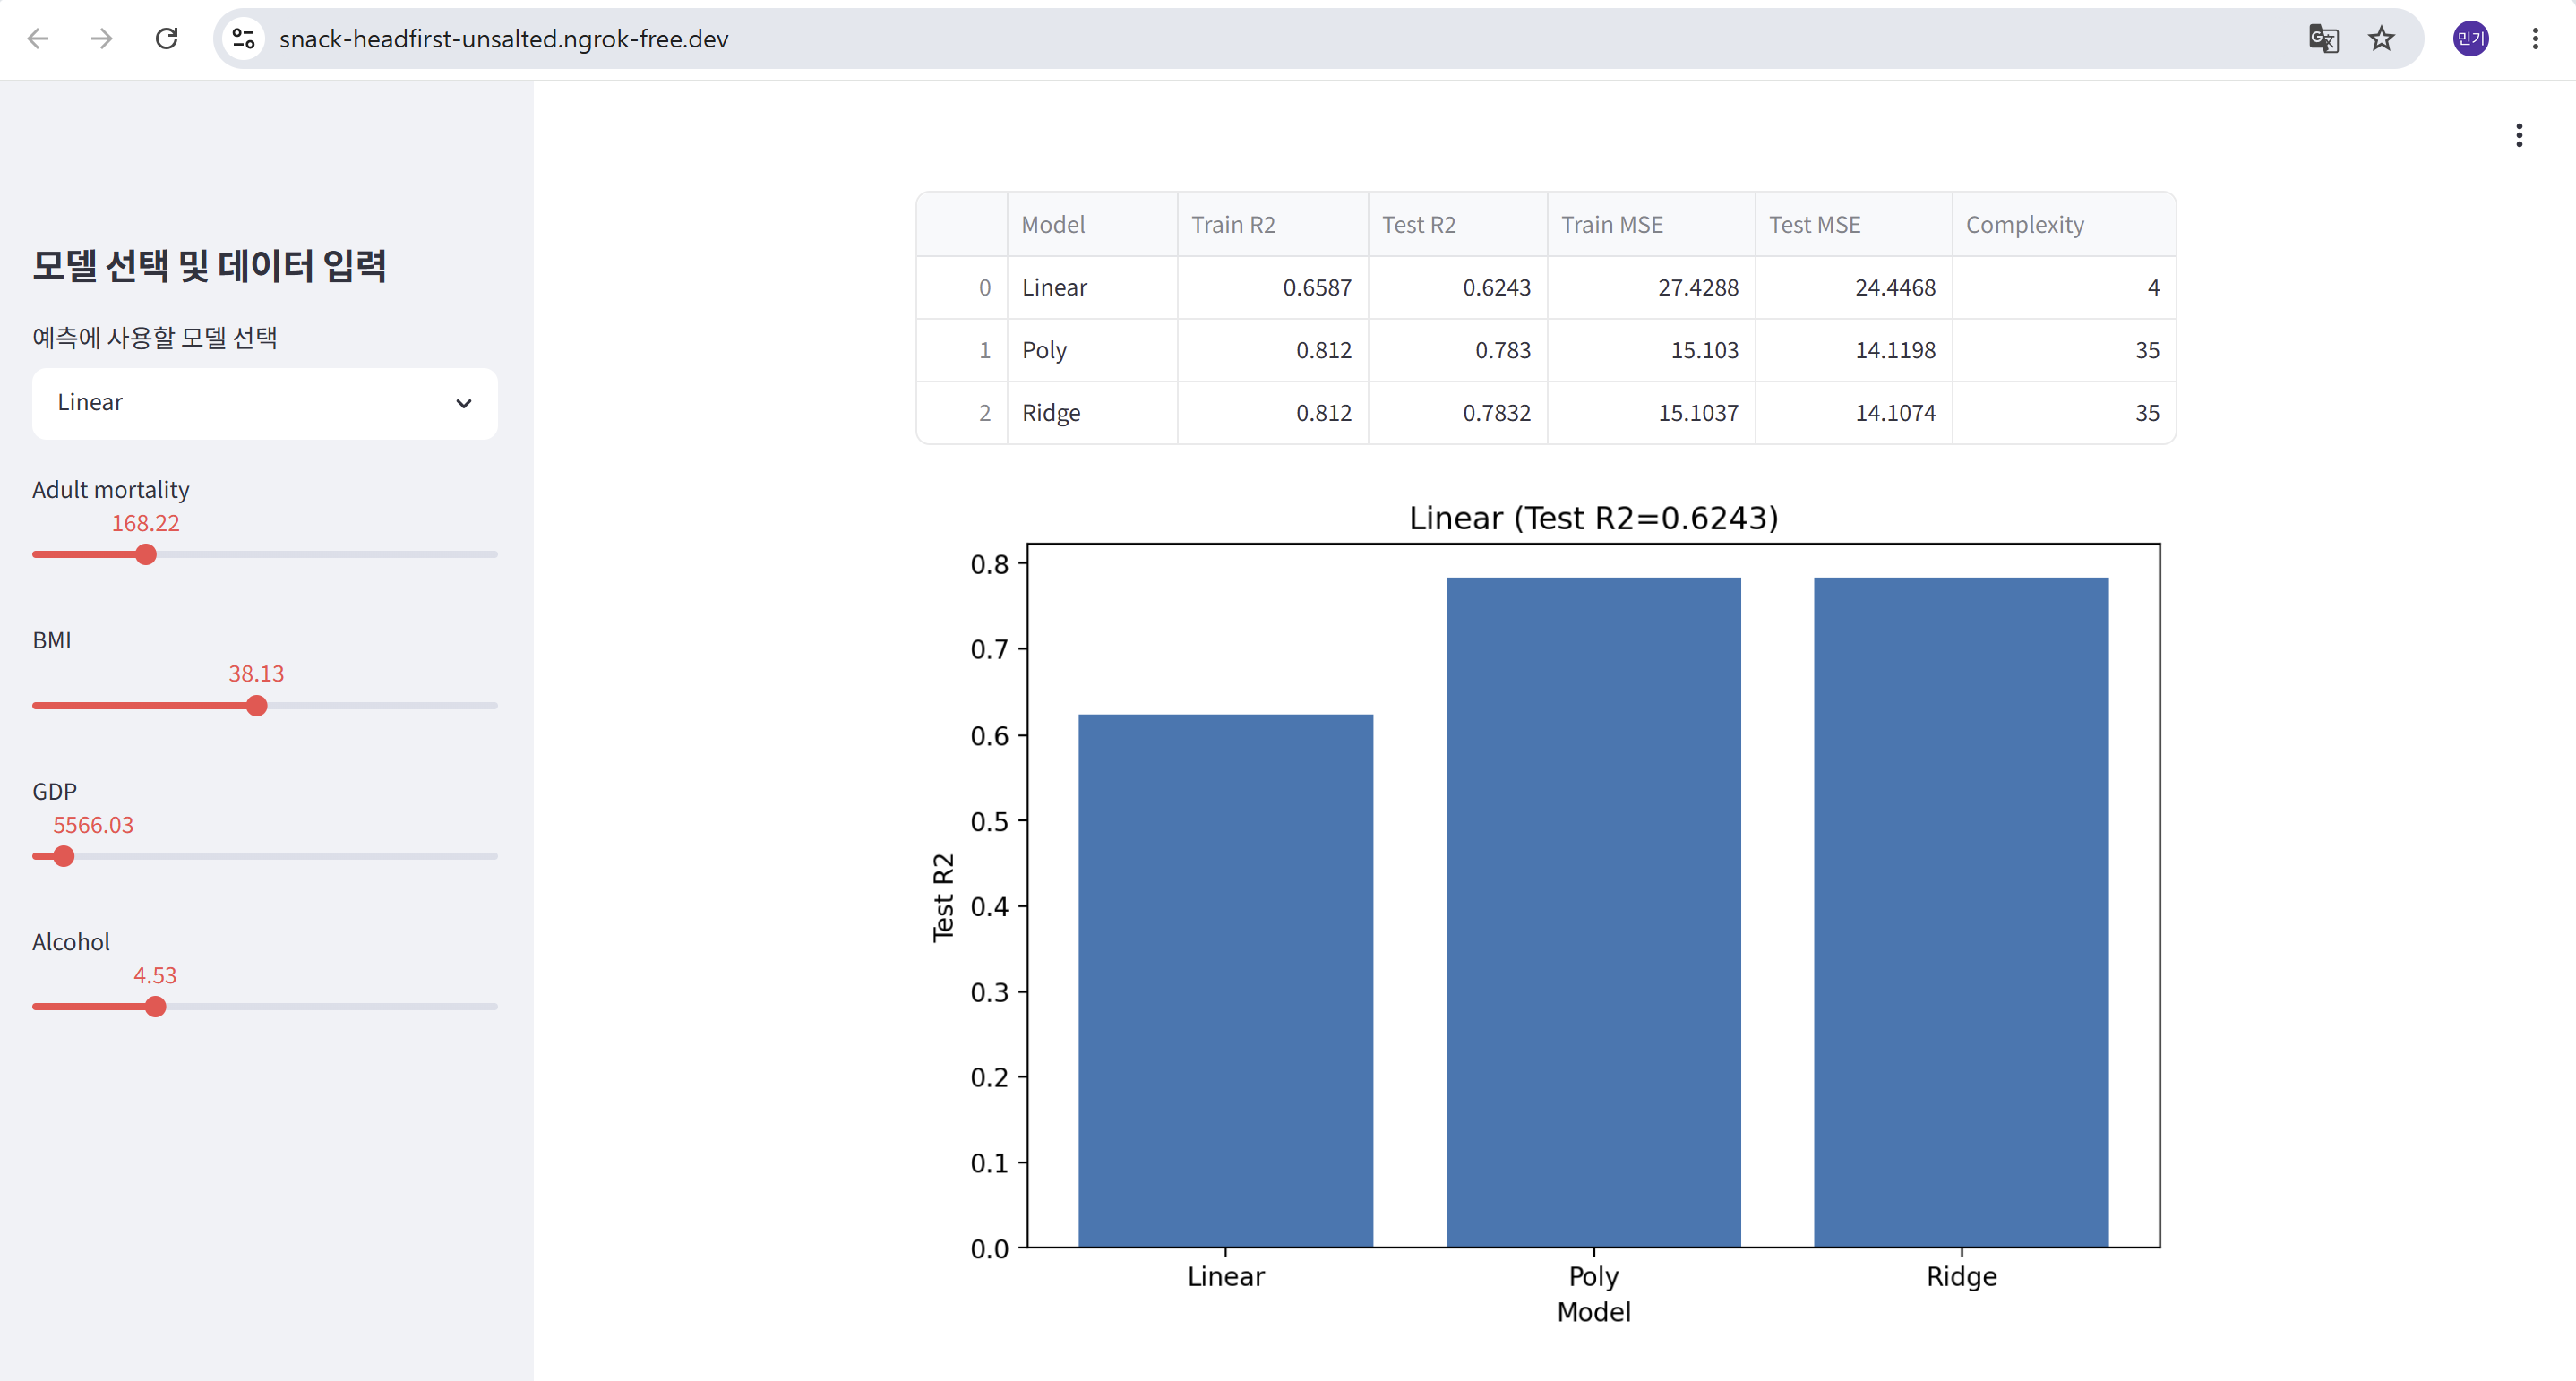

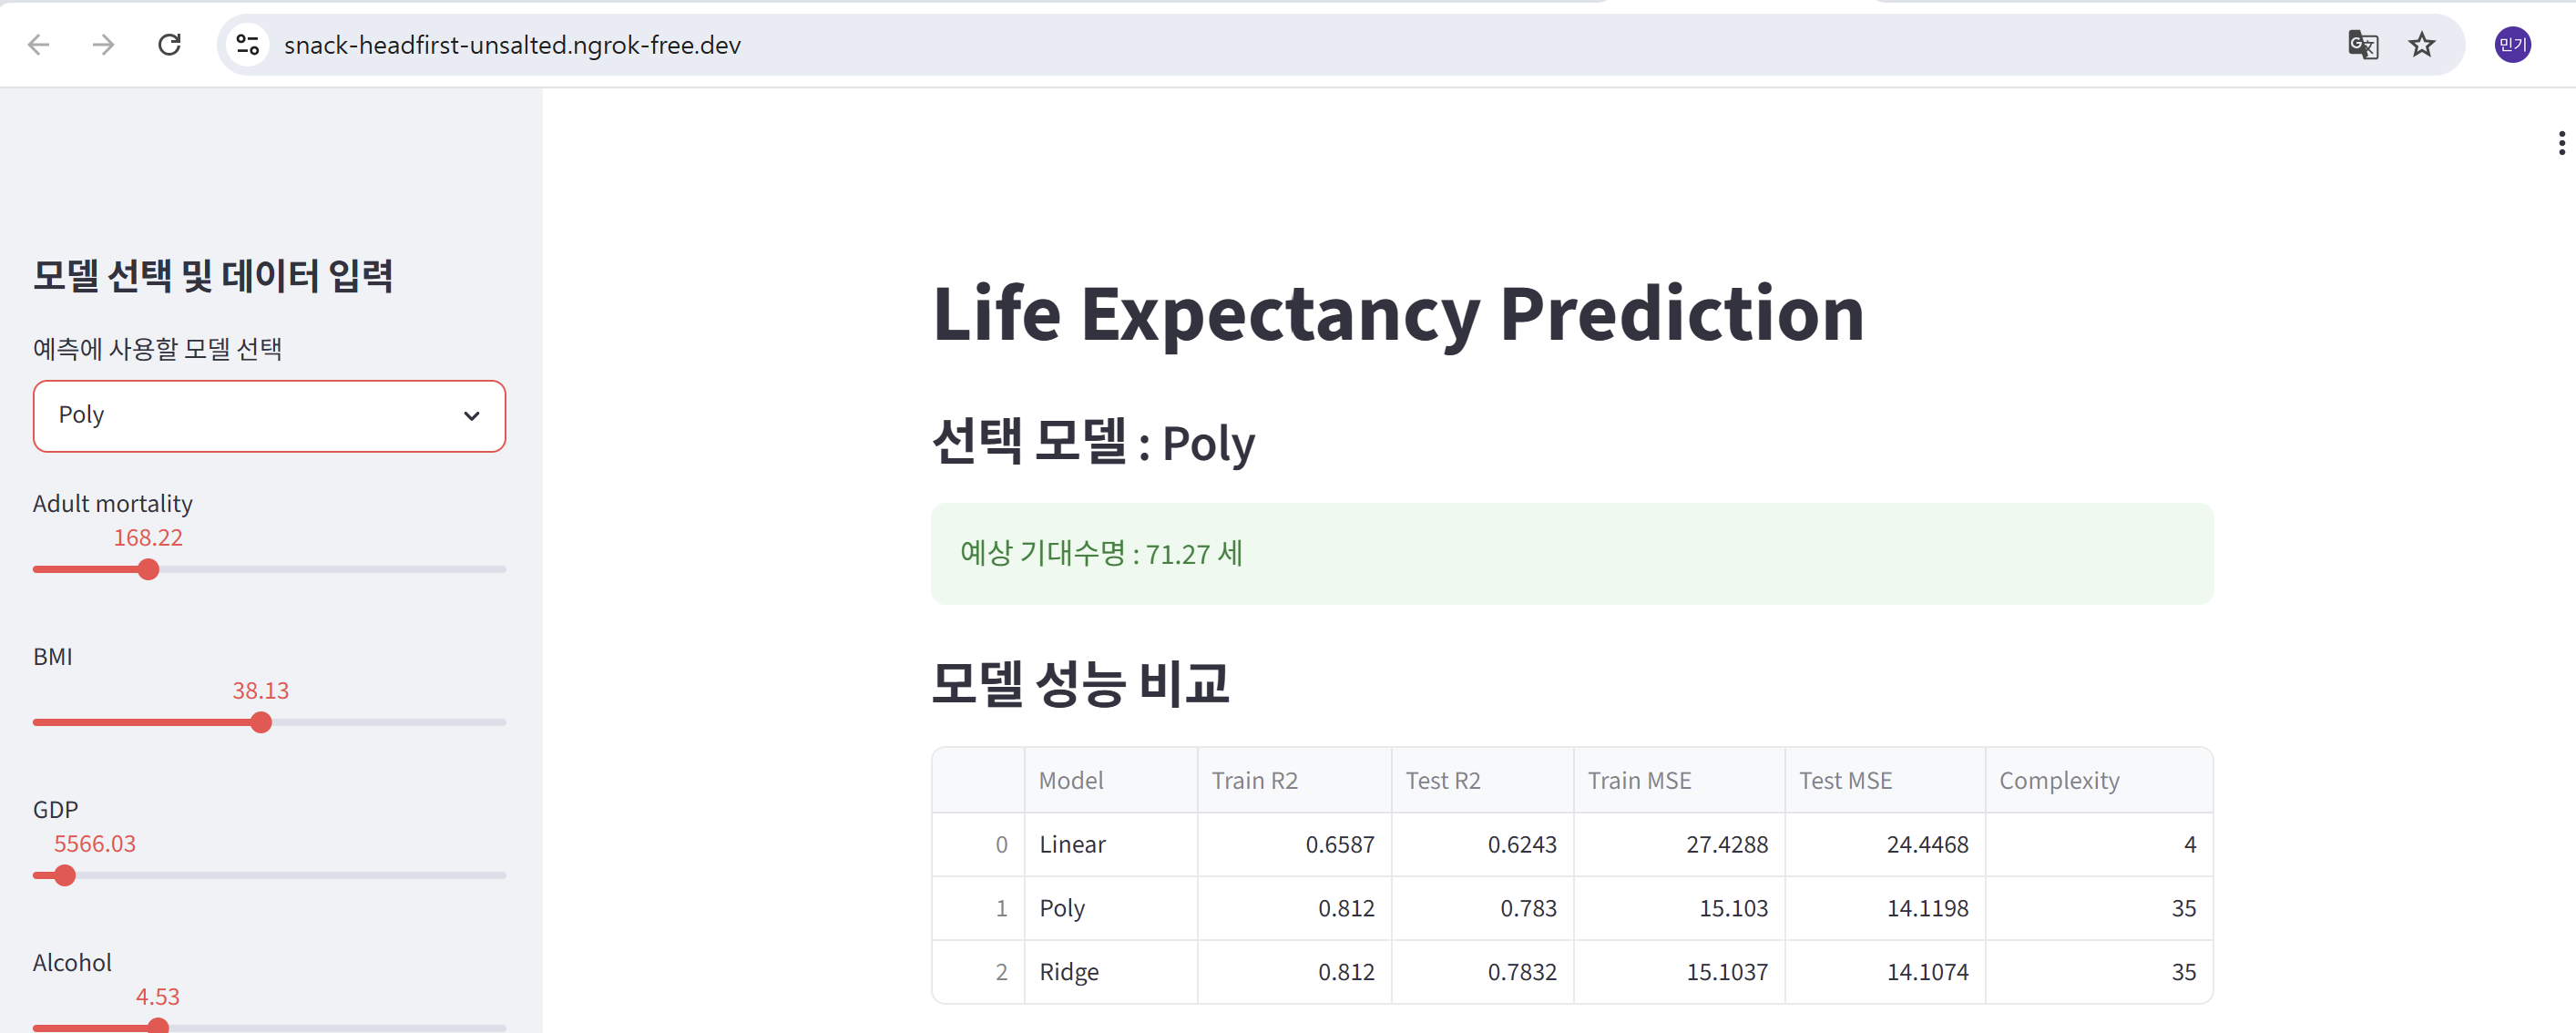

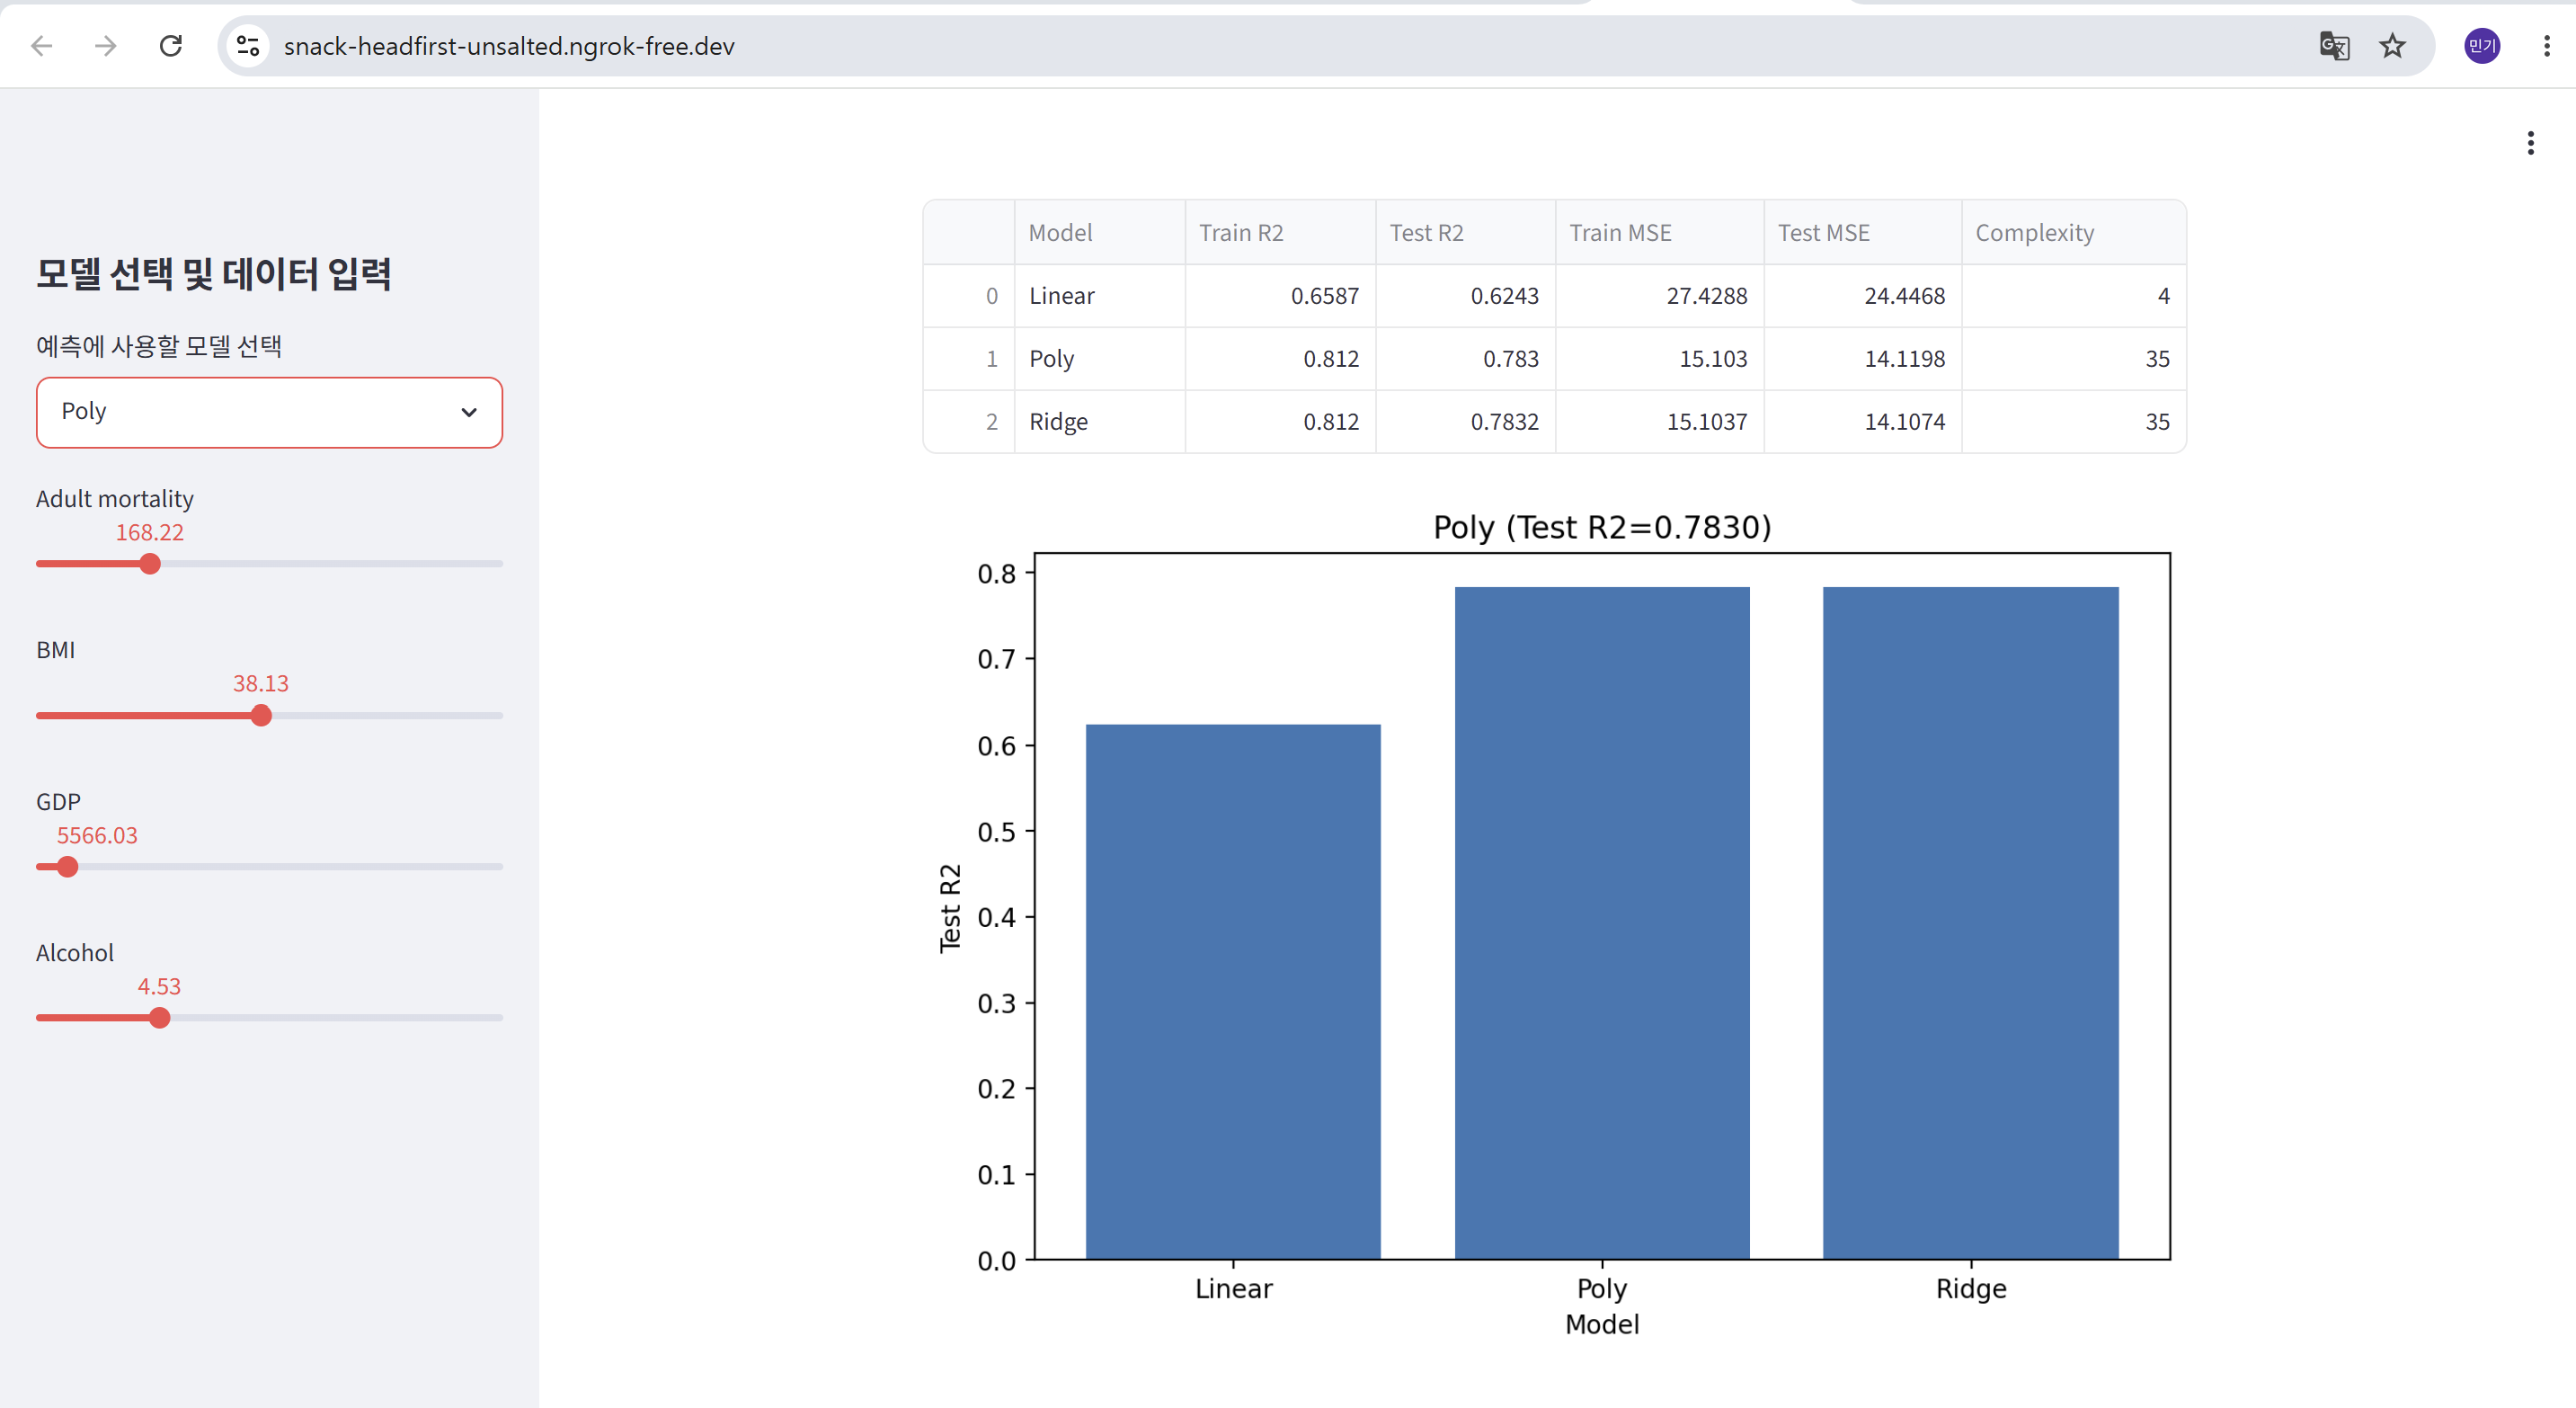

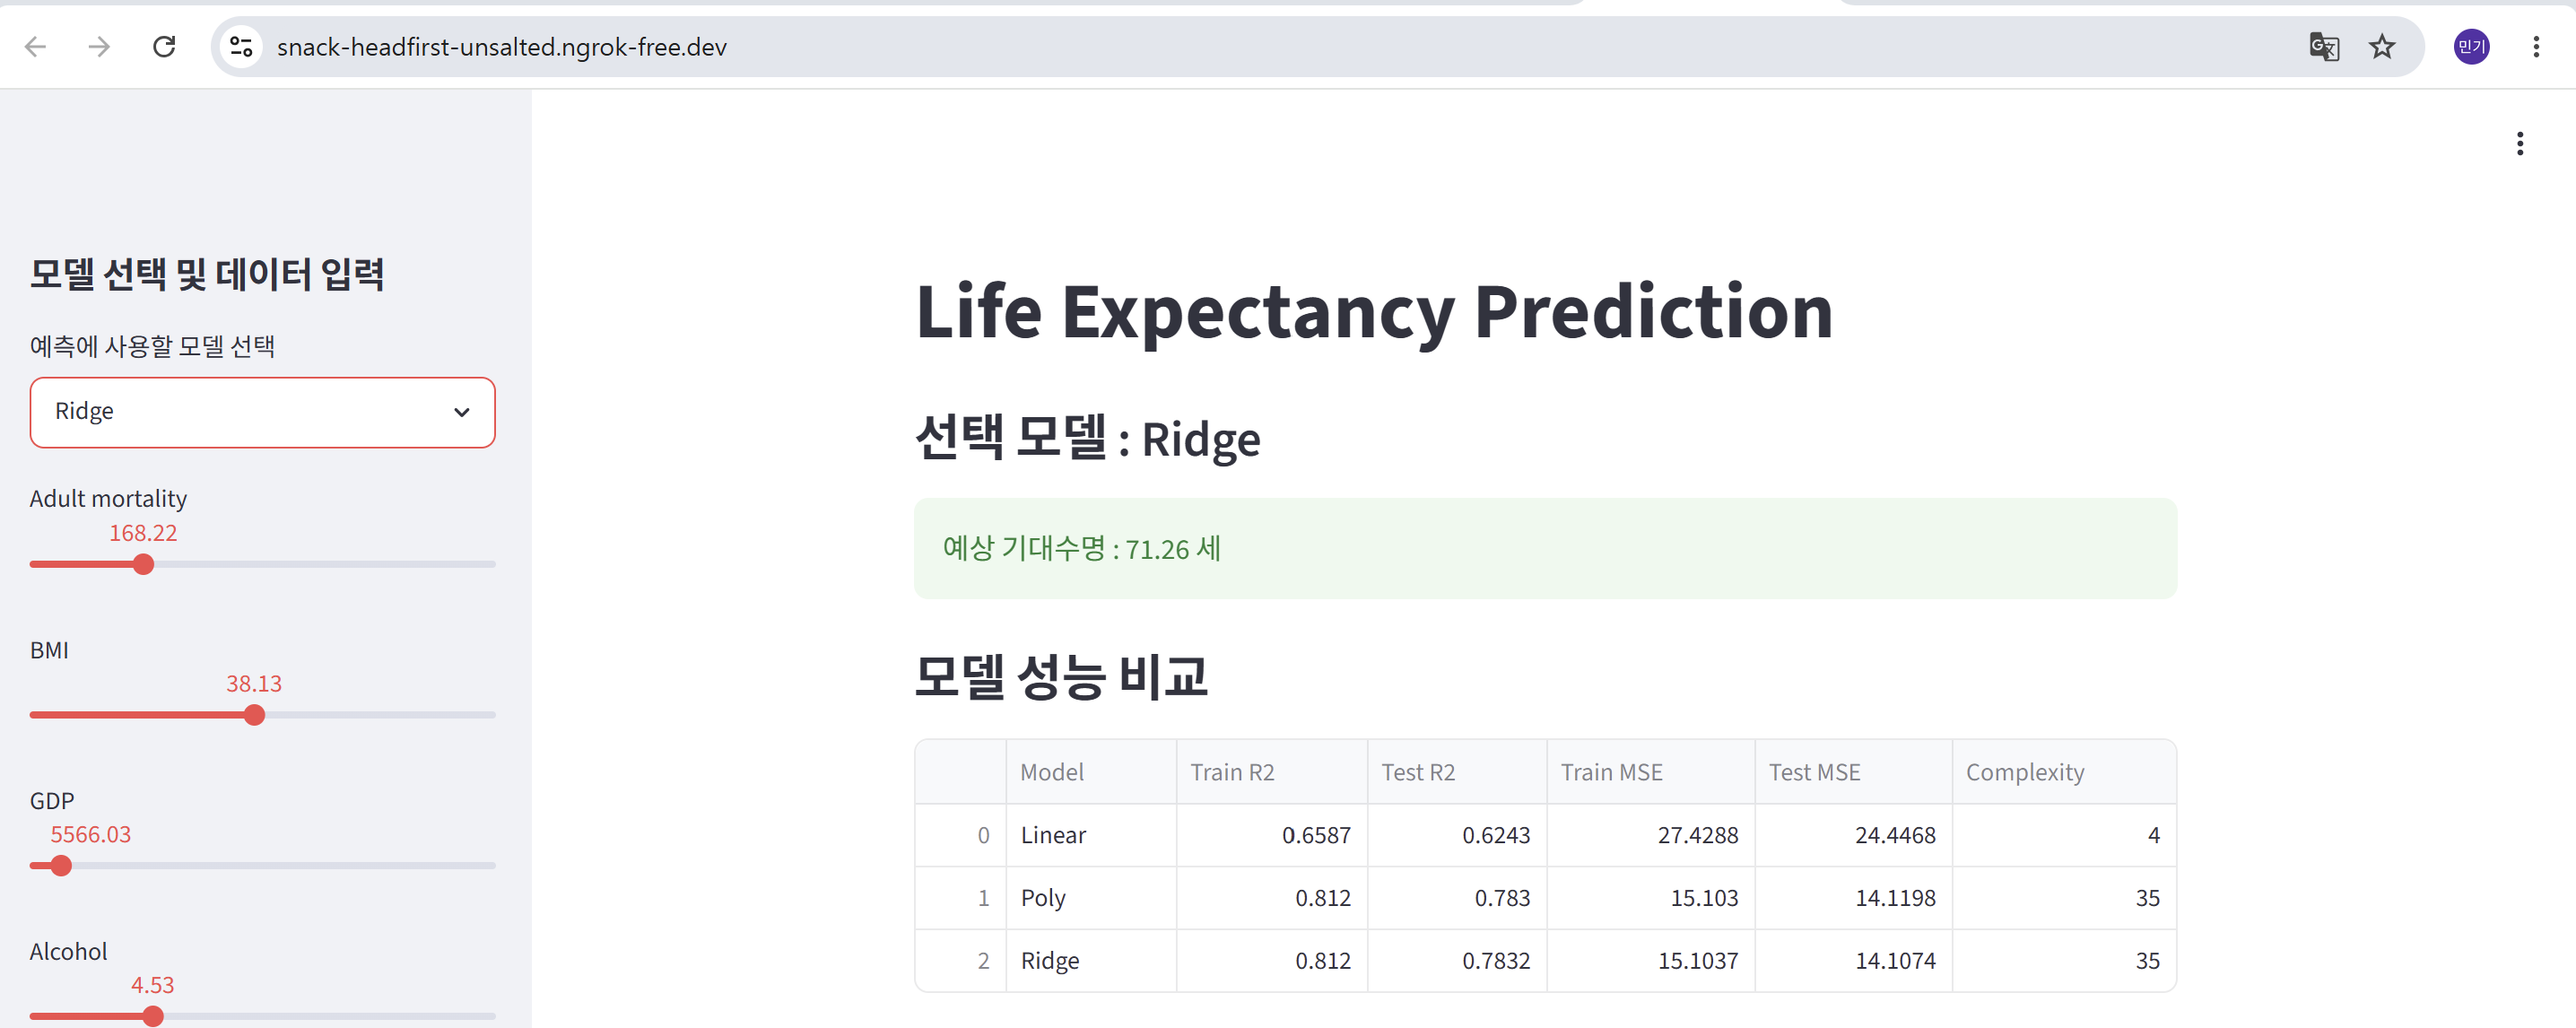

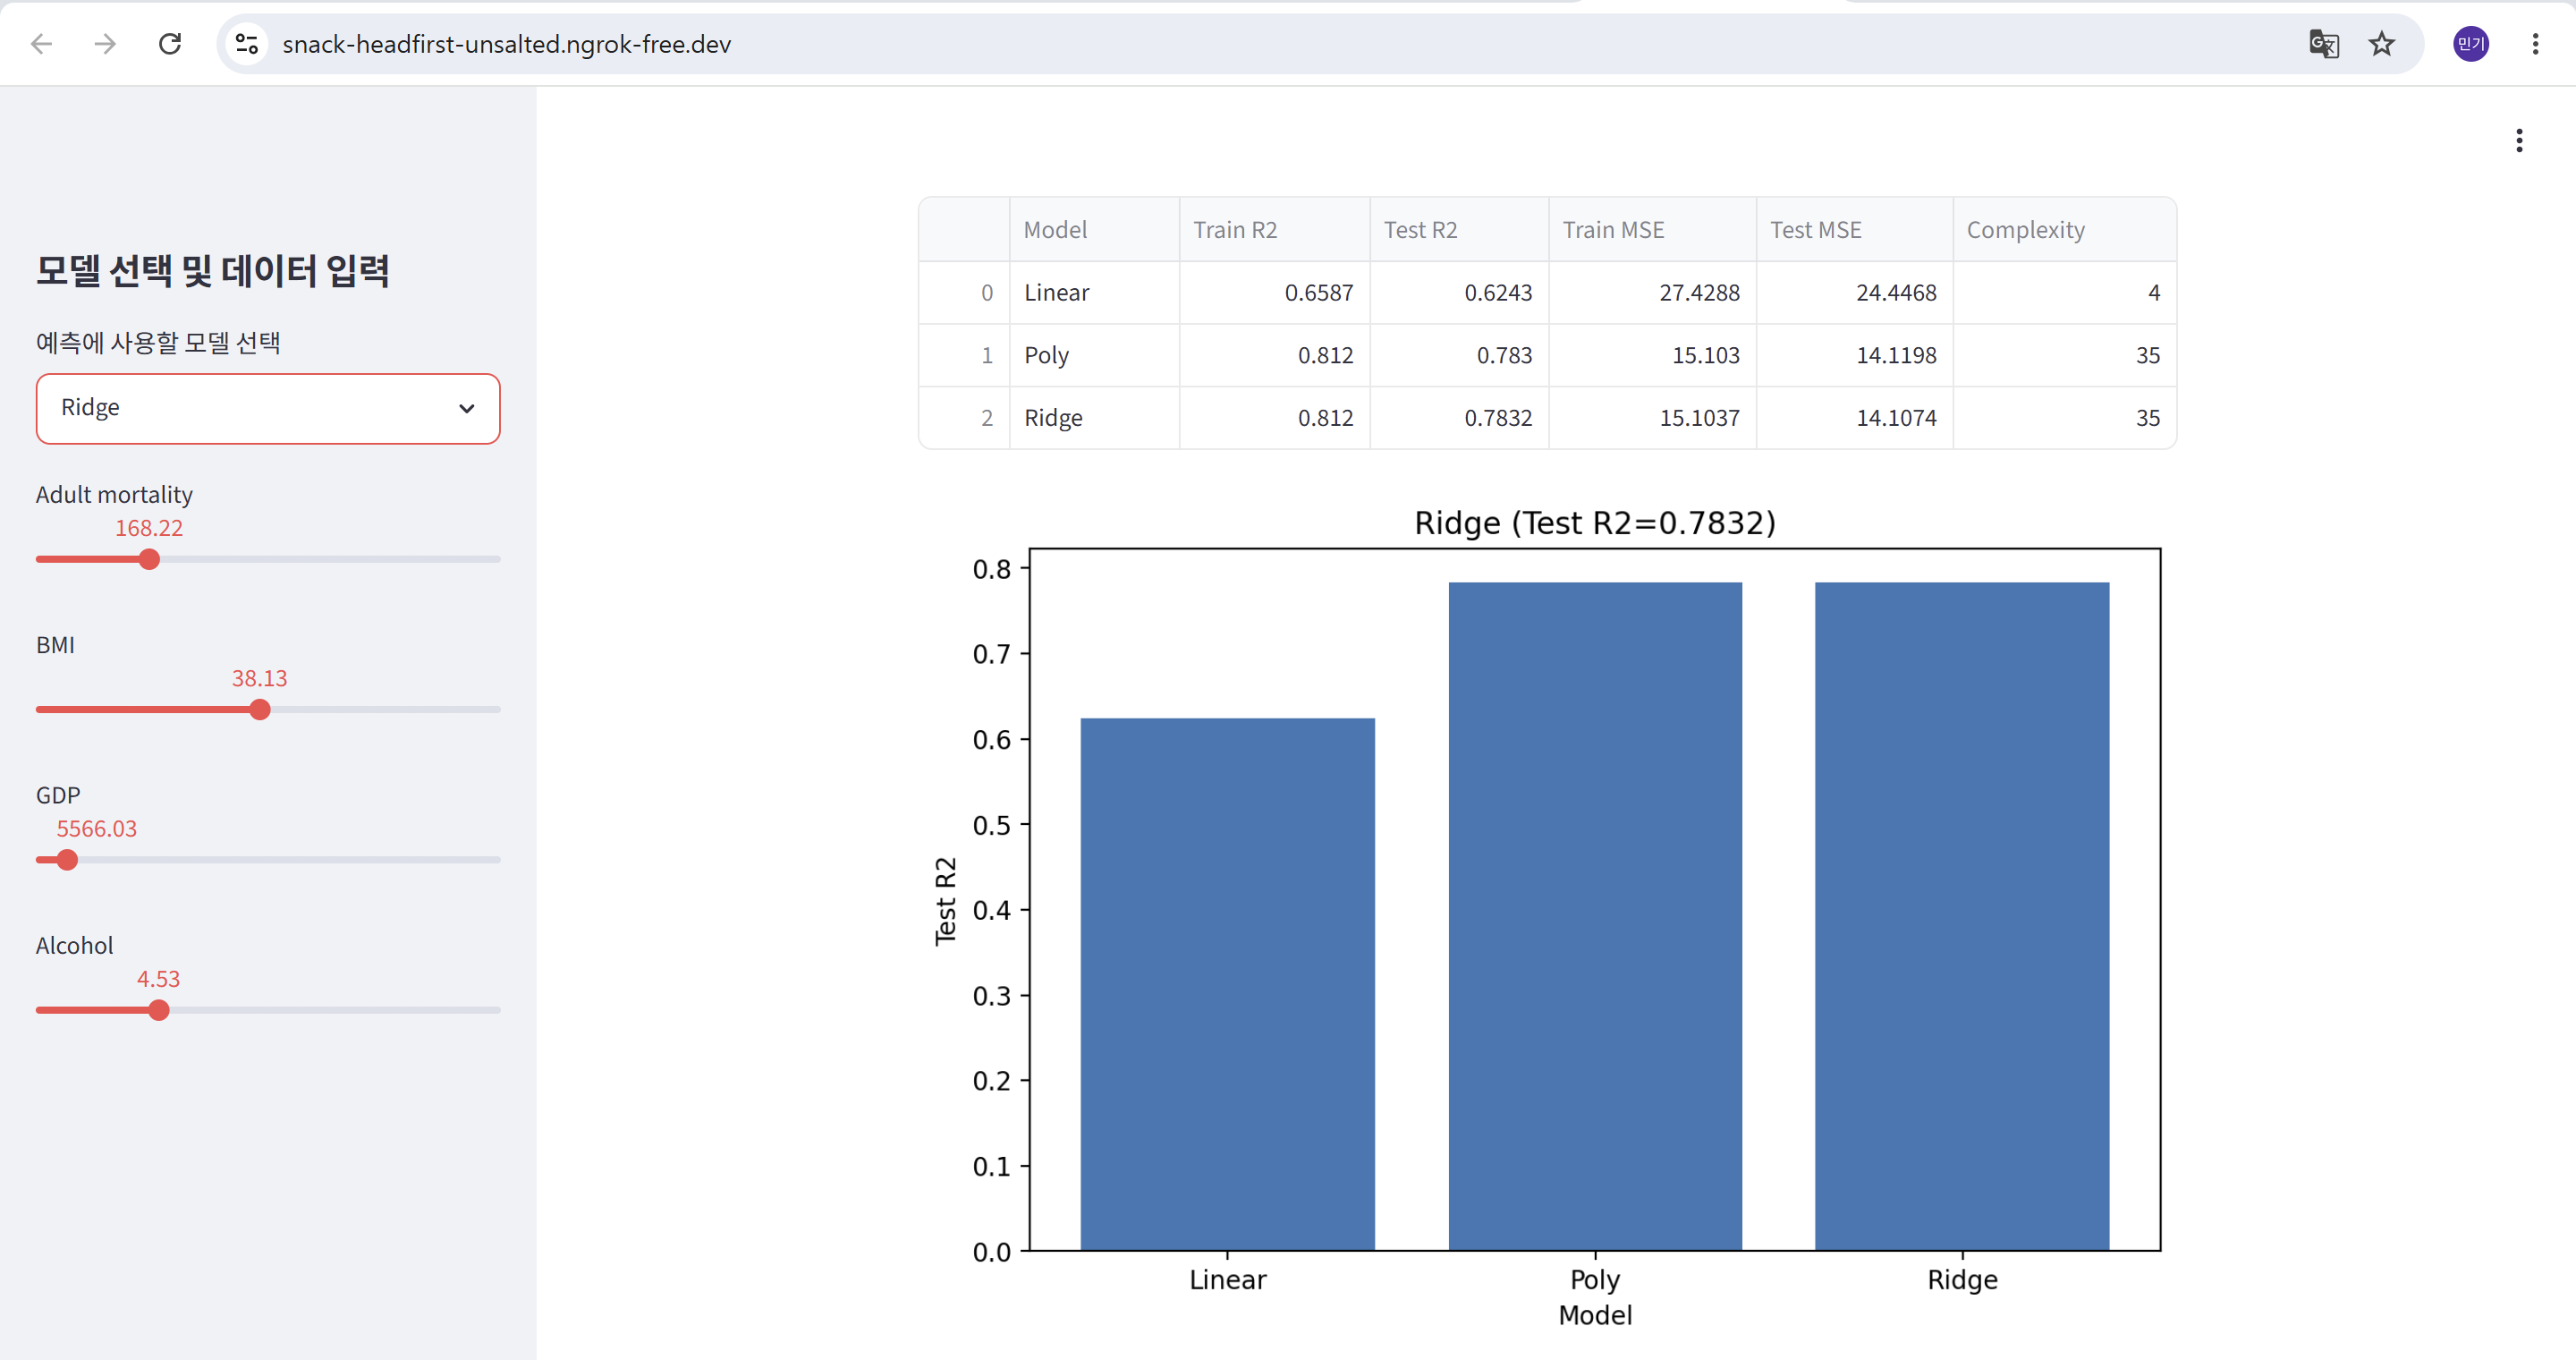